In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import numpy as np

# Bloque 1 - Cobertura del aval ICO vs precio real de mercado por CCAA

**Pregunta:** ¿El tope de precio del aval ICO está calibrado para el mercado real en cada comunidad autónoma?

**Fuentes:**
- Colegio de Registradores: Compraventas de inmuebles uso residencial por provincia 
  (CSV, trimestral 2007–2025)
- ICO: Importes máximos por CCAA (PDF oficial, entrada manual a .xlsx)

**Año de referencia:** 2024 y 2025 (años completos más recientes desde el inicio del programa)

Dataset de topes ICO

https://www.ico.es/documents/20124/777320/Precios+maximos+CCAA-+avales-jovenes-familias.pdf/ecedf846-95a6-66d4-99f4-4941e5bec442?t=1715080874074

In [39]:
df_ico = pd.read_excel("ICO_importes_maximos_por_CCAA.xlsx", 
                       skiprows = 2, 
                       header = 0)
df_ico.columns = ["comunidad_autonoma", "tope_ico"]
df_ico = df_ico.dropna()

df_ico.shape
df_ico.head(20)

,comunidad_autonoma,tope_ico
0,Andalucía,225000
1,Aragón,275000
2,Asturias,250000
3,Baleares,275000
4,Canarias,250000
5,Cantabria,250000
6,Castilla y León,250000
7,Castilla - La Mancha,250000
8,Cataluña,300000
9,Comunidad Valenciana,250000


Dataset de compraventas de inmuebles, uso residencial, por provincia de Registradores

https://opendata.registradores.org/dataset/dataset/compraventas-de-inmuebles-uso-residencial-por-provincia/resource/b779dd2c-db5c-4771-9a50-571bf04ecb15 

In [40]:
df_reg = pd.read_csv("RP_ComprvResid_2007-4t2025.csv", sep=";", encoding="utf-8-sig")

df_reg.shape
df_reg.dtypes
df_reg.head()

,ano,trim,geo,cod-ca,ca,cod-prv,prv,viv-num,viv-imp,viv-pm2,gar-num,gar-imp,gar-pm2,tras-num,tras-imp,tras-pm2,Unnamed: 16
0,2007,1,Nacional,99,ESPAÑA,99,ESPAÑA,893310,174711,"1961,66",345635,16844,"1160,21",66561,6044,"984,48",NaN
1,2007,1,Comunidad,1,Andalucía,98,ANDALUCÍA,176557,140505,"1458,45",60792,16087,"930,40",10691,6000,"902,23",NaN
2,2007,1,Provincia,1,Andalucía,4,Almería,21968,126541,"1471,91",7130,15716,"946,15",1024,4547,"777,96",NaN
3,2007,1,Provincia,1,Andalucía,11,Cádiz,27166,140283,"1423,03",7176,15482,"898,21",1111,5613,"819,35",NaN
4,2007,1,Provincia,1,Andalucía,14,Córdoba,11872,116923,"1187,94",5323,14322,"753,53",499,5033,"677,64",NaN


## Columnas a utilizar

| Columna | Descripción |
|---------|-------------|
| `ano` | Año de la operación |
| `trim` | Trimestre (1–4) |
| `geo` | Nivel geográfico: Comunidad, Provincia |
| `ca` | Nombre de la comunidad autónoma |
| `prv` | Nombre de la provincia |
| `viv-num` | Número de operaciones de compraventa |
| `viv-imp` | Importe medio de compraventa (€) - métrica principal de comparación con el tope ICO |
| `viv-pm2` | Precio medio por metro cuadrado (€/m²) |

 ## Filtro y limpieza
 Convertir a números los datos a trabajar que deberían ser numéricos, como viv-pm2

In [41]:
df_reg["viv-pm2"] = df_reg["viv-pm2"].str.replace(',', '.').pipe(pd.to_numeric, errors = "coerce")

print(df_reg.dtypes)
print(df_reg.isnull().sum())

ano              int64
trim             int64
geo             object
cod-ca           int64
ca              object
cod-prv          int64
prv             object
viv-num          int64
viv-imp          int64
viv-pm2        float64
gar-num          int64
gar-imp          int64
gar-pm2         object
tras-num         int64
tras-imp         int64
tras-pm2        object
Unnamed: 16    float64
dtype: object
ano               0
trim              0
geo               0
cod-ca            0
ca                0
cod-prv           0
prv               0
viv-num           0
viv-imp           0
viv-pm2           0
gar-num           0
gar-imp           0
gar-pm2           0
tras-num          0
tras-imp          0
tras-pm2          0
Unnamed: 16    5472
dtype: int64


Cambiar los nombres para hacerlo más legible

In [42]:
df_reg = df_reg.rename(columns={
    "ano": "año",
    "trim": "trimestre",
    "geo": "geolocalizacion",
    "ca": "comunidad_autonoma",
    "prv": "provincia",
    "viv-num": "cantidad_compraventas",
    "viv-imp": "precio_medio_compraventa",
    "viv-pm2": "precio_medio_m2"
})

print(df_reg.columns.tolist())

df_reg[(df_reg["comunidad_autonoma"] == "Cataluña") & df_reg["año"].isin([2024, 2025])].head(20)

['año', 'trimestre', 'geolocalizacion', 'cod-ca', 'comunidad_autonoma', 'cod-prv', 'provincia', 'cantidad_compraventas', 'precio_medio_compraventa', 'precio_medio_m2', 'gar-num', 'gar-imp', 'gar-pm2', 'tras-num', 'tras-imp', 'tras-pm2', 'Unnamed: 16']


,año,trimestre,geolocalizacion,cod-ca,comunidad_autonoma,cod-prv,provincia,cantidad_compraventas,precio_medio_compraventa,precio_medio_m2,gar-num,gar-imp,gar-pm2,tras-num,tras-imp,tras-pm2,Unnamed: 16
4935,2024,1,Comunidad,9,Cataluña,98,CATALUÑA,90563,219808,2470.11,37314,15664,"1174,48",5142,6273,"1149,07",NaN
4936,2024,1,Provincia,9,Cataluña,8,Barcelona,57837,249354,2836.04,25165,16996,"1307,91",3348,7031,"1291,21",NaN
4937,2024,1,Provincia,9,Cataluña,17,Girona,13306,213797,2245.54,5195,14521,"1004,60",661,5766,"986,11",NaN
4938,2024,1,Provincia,9,Cataluña,25,Lleida,5027,138927,1352.56,2263,11072,"769,55",402,3202,"690,13",NaN
4939,2024,1,Provincia,9,Cataluña,43,Tarragona,14393,135742,1603.06,4691,12523,"901,19",731,4889,"899,73",NaN
5007,2024,2,Comunidad,9,Cataluña,98,CATALUÑA,88414,220793,2476.55,36508,15494,"1162,22",5270,6267,"1109,38",NaN
5008,2024,2,Provincia,9,Cataluña,8,Barcelona,56538,250647,2843.10,24624,16876,"1297,90",3483,7064,"1211,99",NaN
5009,2024,2,Provincia,9,Cataluña,17,Girona,12797,214079,2245.46,5121,14417,"996,68",714,5590,"1055,28",NaN
5010,2024,2,Provincia,9,Cataluña,25,Lleida,4993,139920,1335.44,2173,11072,"769,73",383,2884,"637,33",NaN
5011,2024,2,Provincia,9,Cataluña,43,Tarragona,14086,135818,1615.03,4590,11919,"868,37",690,4766,"897,97",NaN


## Dataframe segmentación de comunidad autónoma (CCAA)
Filtrado por columnas y filas de interés.

In [43]:
df_ccaa_24_25 = df_reg[(df_reg["geolocalizacion"] == "Comunidad") & 
                       (df_reg["año"].isin([2024, 2025]))][["comunidad_autonoma", "trimestre", "año", "cantidad_compraventas", "precio_medio_compraventa", "precio_medio_m2"]].copy().reset_index(drop = True)

print(f"Tamaño del df: {df_ccaa_24_25.shape}")
print(f"\nTipos de datos:\n{df_ccaa_24_25.dtypes}")
print(f"\nNulos por columna:\n{df_ccaa_24_25.isnull().sum()}")
print(f"\nNúmero de CCAA únicas: {df_ccaa_24_25["comunidad_autonoma"].nunique()}")
print(f"Trimestres disponibles: {df_ccaa_24_25["trimestre"].unique()}")



Tamaño del df: (152, 6)

Tipos de datos:
comunidad_autonoma           object
trimestre                     int64
año                           int64
cantidad_compraventas         int64
precio_medio_compraventa      int64
precio_medio_m2             float64
dtype: object

Nulos por columna:
comunidad_autonoma          0
trimestre                   0
año                         0
cantidad_compraventas       0
precio_medio_compraventa    0
precio_medio_m2             0
dtype: int64

Número de CCAA únicas: 19
Trimestres disponibles: [1 2 3 4]


Calcular la cantidad de ventas por año y el promedio de venta por m2 por comunidad autónoma

In [44]:
df_ccaa_anual = df_ccaa_24_25.groupby(["comunidad_autonoma", "año"]).agg({
    "cantidad_compraventas" : "sum",
    "precio_medio_compraventa" : "mean",
    "precio_medio_m2": "mean"
}).round(2).reset_index()

Homogenizar los nombres de las comunidades autónomas entre el df de ico y el df de ccaa anual

In [45]:
print("Registradores:", sorted(df_ccaa_anual["comunidad_autonoma"].tolist()))
print("ICO:", sorted(df_ico["comunidad_autonoma"].tolist()))

mapeo_ccaa = {
    'Asturias': 'Principado de Asturias',
    'Baleares': 'Illes Balears',
    'Castilla - La Mancha': 'Castilla-La Mancha',
    'Comunidad Valenciana': 'Comunitat Valenciana',
    'Madrid': 'Comunidad de Madrid',
    'Murcia': 'Región de Murcia',
    'Navarra': 'C. Foral de Navarra',
    'Rioja': 'La Rioja'
}

df_ico["comunidad_autonoma"] = df_ico["comunidad_autonoma"].replace(mapeo_ccaa)
print(sorted(df_ico["comunidad_autonoma"].tolist()))

Registradores: ['Andalucía', 'Andalucía', 'Aragón', 'Aragón', 'C. Foral de Navarra', 'C. Foral de Navarra', 'Canarias', 'Canarias', 'Cantabria', 'Cantabria', 'Castilla y León', 'Castilla y León', 'Castilla-La Mancha', 'Castilla-La Mancha', 'Cataluña', 'Cataluña', 'Ceuta', 'Ceuta', 'Comunidad de Madrid', 'Comunidad de Madrid', 'Comunitat Valenciana', 'Comunitat Valenciana', 'Extremadura', 'Extremadura', 'Galicia', 'Galicia', 'Illes Balears', 'Illes Balears', 'La Rioja', 'La Rioja', 'Melilla', 'Melilla', 'País Vasco', 'País Vasco', 'Principado de Asturias', 'Principado de Asturias', 'Región de Murcia', 'Región de Murcia']
ICO: ['Andalucía', 'Aragón', 'Asturias', 'Baleares', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla y León', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
['Andalucía', 'Aragón', 'C. Foral de Navarra', 'Canarias', 'Cantabria', 'Castilla y León', 'Castilla-La Mancha', 'C

In [46]:
df_ccaa = pd.merge(df_ico, df_ccaa_anual, on = "comunidad_autonoma", how = "left")
df_ccaa

,comunidad_autonoma,tope_ico,año,cantidad_compraventas,precio_medio_compraventa,precio_medio_m2
0,Andalucía,225000,2024,465757,181859.00,1749.82
1,Andalucía,225000,2025,542570,194469.50,1891.88
2,Aragón,275000,2024,62016,134758.25,1547.35
3,Aragón,275000,2025,72554,143243.00,1668.09
4,Principado de Asturias,250000,2024,51571,115712.00,1337.06
5,Principado de Asturias,250000,2025,62882,124854.00,1444.13
6,Illes Balears,275000,2024,53826,366092.00,3466.58
7,Illes Balears,275000,2025,58538,402166.00,3847.33
8,Canarias,250000,2024,95405,184322.25,2324.39
9,Canarias,250000,2025,101244,202770.50,2560.34


Se crea una columna para calcular la brecha del ICO con el precio promedio del mercado.

In [47]:
df_ccaa["brecha_ico"] = df_ccaa["tope_ico"] - df_ccaa["precio_medio_compraventa"]
df_ccaa = df_ccaa[["comunidad_autonoma", "año", "tope_ico", "precio_medio_compraventa", "brecha_ico"]].copy()
df_ccaa

,comunidad_autonoma,año,tope_ico,precio_medio_compraventa,brecha_ico
0,Andalucía,2024,225000,181859.00,43141.00
1,Andalucía,2025,225000,194469.50,30530.50
2,Aragón,2024,275000,134758.25,140241.75
3,Aragón,2025,275000,143243.00,131757.00
4,Principado de Asturias,2024,250000,115712.00,134288.00
5,Principado de Asturias,2025,250000,124854.00,125146.00
6,Illes Balears,2024,275000,366092.00,-91092.00
7,Illes Balears,2025,275000,402166.00,-127166.00
8,Canarias,2024,250000,184322.25,65677.75
9,Canarias,2025,250000,202770.50,47229.50


- Brecha negativa = el precio promedio de mercado está por debajo del tope ICO, el programa sí cubriría esa zona
- Brecha positiva = el precio supera el tope el programa no alcanza. Solo Madrid (2024 y 2025) e Illes Balears (ambos años) tienen brecha positiva.

*En los mercados más tensionados (Madrid y Baleares) el tope ICO es insuficiente, y además la brecha se amplía: el precio de mercado creció un 12,77% en Madrid y un 9,85% en Baleares entre 2024 y 2025, ampliando la brecha con el tope ICO, Madrid pasa de +2.845€ a +44.722€, y Baleares de +91.092€ a +127.166€*



## Dataframe segmentación provincias

In [48]:
df_prov_24_25 = df_reg[(df_reg["geolocalizacion"] == "Provincia") & 
                      (df_reg["año"].isin([2024, 2025]))][["comunidad_autonoma", "provincia", "año", "cantidad_compraventas", "precio_medio_compraventa", "precio_medio_m2"]].copy().reset_index(drop = True)
df_prov_24_25.head()

,comunidad_autonoma,provincia,año,cantidad_compraventas,precio_medio_compraventa,precio_medio_m2
0,Andalucía,Almería,2024,12526,111203,1201.05
1,Andalucía,Cádiz,2024,14479,160392,1598.16
2,Andalucía,Córdoba,2024,8205,123695,1209.54
3,Andalucía,Granada,2024,11983,128519,1259.85
4,Andalucía,Huelva,2024,6608,123017,1296.85


In [49]:
df_dispersion = df_prov_24_25.groupby(["comunidad_autonoma", "año"]).apply(
    lambda x: pd.Series({
        "precio_minimo": x["precio_medio_compraventa"].min(),
        "provincia_minimo": x.loc[x["precio_medio_compraventa"].idxmin(), "provincia"],
        "precio_maximo": x["precio_medio_compraventa"].max(),
        "provincia_maximo": x.loc[x["precio_medio_compraventa"].idxmax(), "provincia"]
    }),
    include_groups = False  # Para silenciar el FutureWarning que me sale
).round(2).reset_index()

df_dispersion.head(10)

df_bloque1_prov = pd.merge(df_dispersion, df_ico, on = "comunidad_autonoma", how = "left")
df_bloque1_prov.head(50)

,comunidad_autonoma,año,precio_minimo,provincia_minimo,precio_maximo,provincia_maximo,tope_ico
0,Andalucía,2024,78281,Jaén,298593,Málaga,225000
1,Andalucía,2025,84649,Jaén,325945,Málaga,225000
2,Aragón,2024,81868,Teruel,148561,Zaragoza,275000
3,Aragón,2025,84463,Teruel,155216,Zaragoza,275000
4,C. Foral de Navarra,2024,195137,Navarra,200162,Navarra,300000
5,C. Foral de Navarra,2025,201072,Navarra,211965,Navarra,300000
6,Canarias,2024,173644,Las Palmas,198035,Santa Cruz de Tenerife,250000
7,Canarias,2025,184106,Las Palmas,225465,Santa Cruz de Tenerife,250000
8,Cantabria,2024,150322,Cantabria,166378,Cantabria,250000
9,Cantabria,2025,172039,Cantabria,187107,Cantabria,250000


## INE salario promedio

In [50]:
df_salario = pd.read_csv("salario_INE.csv", sep=";", encoding="utf-8-sig")

print(df_salario.dtypes)
df_salario.head()

Comunidades y Ciudades Autónomas    object
Edad del trabajador                 object
Sexo                                object
Periodo                              int64
Total                               object
dtype: object


,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
0,Total Nacional,Todas las edades,Ambos sexos,2024,"29.540,26"
1,Total Nacional,Todas las edades,Ambos sexos,2023,"28.049,94"
2,Total Nacional,Todas las edades,Ambos sexos,2022,"26.948,87"
3,Total Nacional,Todas las edades,Ambos sexos,2021,"25.896,82"
4,Total Nacional,Todas las edades,Ambos sexos,2020,"25.165,51"


Limpiar las celdas numéricas

In [51]:
df_salario["Total"] = (df_salario["Total"]
                       .str.replace('.', '', regex = False)  # eliminar punto de miles
                       .str.replace(',', '.')              # cambiar coma decimal por punto
                       .pipe(pd.to_numeric, errors = "coerce")
)

print(df_salario.dtypes)
df_salario.head()

Comunidades y Ciudades Autónomas     object
Edad del trabajador                  object
Sexo                                 object
Periodo                               int64
Total                               float64
dtype: object


,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
0,Total Nacional,Todas las edades,Ambos sexos,2024,29540.26
1,Total Nacional,Todas las edades,Ambos sexos,2023,28049.94
2,Total Nacional,Todas las edades,Ambos sexos,2022,26948.87
3,Total Nacional,Todas las edades,Ambos sexos,2021,25896.82
4,Total Nacional,Todas las edades,Ambos sexos,2020,25165.51


In [52]:
df_salario["Edad del trabajador"].value_counts()

Edad del trabajador
Todas las edades    918
Menos de 25 años    918
De 25 a 34 años     918
De 35 a 44 años     918
De 45 a 54 años     918
55 y más años       918
Name: count, dtype: int64

In [53]:
mapeo_salarios = {
    "Asturias, Principado de": "Principado de Asturias",
    "Balears, Illes": "Illes Balears",
    "Castilla - La Mancha": "Castilla-La Mancha",
    "Madrid, Comunidad de": "Comunidad de Madrid",
    "Murcia, Región de": "Región de Murcia",
    "Navarra, Comunidad Foral de": "C. Foral de Navarra",
    "Rioja, La": "La Rioja"
}

df_salario["Comunidades y Ciudades Autónomas"] = df_salario["Comunidades y Ciudades Autónomas"].replace(mapeo_salarios)
df_salario

,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
0,Total Nacional,Todas las edades,Ambos sexos,2024,29540.26
1,Total Nacional,Todas las edades,Ambos sexos,2023,28049.94
2,Total Nacional,Todas las edades,Ambos sexos,2022,26948.87
3,Total Nacional,Todas las edades,Ambos sexos,2021,25896.82
4,Total Nacional,Todas las edades,Ambos sexos,2020,25165.51
...,...,...,...,...,...
5503,La Rioja,55 y más años,Hombres,2012,-25361.70
5504,La Rioja,55 y más años,Hombres,2011,-28084.19
5505,La Rioja,55 y más años,Hombres,2010,-28756.01
5506,La Rioja,55 y más años,Hombres,2009,-25436.03


Se trabaja únicamente con el tramo de 25 a 34 años. El tramo de menores de 25 años se descarta porque el INE publica la mayoría de sus valores con indicador de baja fiabilidad muestral (valores negativos en el CSV), lo que los hace no utilizables para el análisis territorial.

In [54]:
df_jovenes = df_salario[(df_salario["Edad del trabajador"] == "De 25 a 34 años") & 
                        (df_salario["Periodo"] >= 2024)]

df_jovenes.isnull().sum()

Comunidades y Ciudades Autónomas    0
Edad del trabajador                 0
Sexo                                0
Periodo                             0
Total                               0
dtype: int64

Se convierte la tabla de salarios en un pivot table

In [55]:
df_salario_pivot = df_jovenes.pivot_table(
    index = "Comunidades y Ciudades Autónomas",
    columns = "Sexo",
    values = "Total"
).round(2).reset_index()

df_salario_pivot.columns.name = None
df_salario_pivot = df_salario_pivot[df_salario_pivot["Comunidades y Ciudades Autónomas"] != "Total Nacional"]

df_salario_pivot

,Comunidades y Ciudades Autónomas,Ambos sexos,Hombres,Mujeres
0,Andalucía,20579.95,22036.01,19197.66
1,Aragón,23502.30,24911.95,21789.86
2,C. Foral de Navarra,27731.40,29032.81,26383.73
3,Canarias,20573.90,21426.91,19600.55
4,Cantabria,21678.54,-22659.04,-20489.07
5,Castilla y León,23827.80,24689.65,22664.63
6,Castilla-La Mancha,21425.35,21785.36,21000.21
7,Cataluña,28269.97,29625.35,26937.89
8,Comunidad de Madrid,29361.99,30789.11,27651.84
9,Comunitat Valenciana,23074.87,24519.42,21577.36


El INE publica con valor negativo aquellos datos cuya muestra es insuficiente para garantizar su fiabilidad estadística. Estos valores no representan salarios reales y se convierten a NaN para excluirlos del análisis.

Se aplica clip(lower=0) para convertir negativos a 0, seguido de replace(0, pd.NA) para transformarlos en NaN. Dado que ningún salario real puede ser 0, esta operación no elimina datos válidos.

In [56]:
cols_numericas = ["Ambos sexos", "Hombres", "Mujeres"]

df_salario_pivot[cols_numericas] = df_salario_pivot[cols_numericas].clip(lower = 0).replace(0, pd.NA)

df_salario_pivot

,Comunidades y Ciudades Autónomas,Ambos sexos,Hombres,Mujeres
0,Andalucía,20579.95,22036.01,19197.66
1,Aragón,23502.30,24911.95,21789.86
2,C. Foral de Navarra,27731.40,29032.81,26383.73
3,Canarias,20573.90,21426.91,19600.55
4,Cantabria,21678.54,<NA>,<NA>
5,Castilla y León,23827.80,24689.65,22664.63
6,Castilla-La Mancha,21425.35,21785.36,21000.21
7,Cataluña,28269.97,29625.35,26937.89
8,Comunidad de Madrid,29361.99,30789.11,27651.84
9,Comunitat Valenciana,23074.87,24519.42,21577.36


In [57]:
df_salario_pivot = df_salario_pivot.rename(columns={
    "Comunidades y Ciudades Autónomas": "comunidad_autonoma",
    "Ambos sexos" : "salario_HyM",
    "Hombres" : "salario_H",
    "Mujeres" : "salario_M"
    })

df_salario_pivot["salario_H"] = pd.to_numeric(df_salario_pivot["salario_H"], errors="coerce")
df_salario_pivot["salario_M"] = pd.to_numeric(df_salario_pivot["salario_M"], errors="coerce")

df_salario_pivot

,comunidad_autonoma,salario_HyM,salario_H,salario_M
0,Andalucía,20579.95,22036.01,19197.66
1,Aragón,23502.30,24911.95,21789.86
2,C. Foral de Navarra,27731.40,29032.81,26383.73
3,Canarias,20573.90,21426.91,19600.55
4,Cantabria,21678.54,NaN,NaN
5,Castilla y León,23827.80,24689.65,22664.63
6,Castilla-La Mancha,21425.35,21785.36,21000.21
7,Cataluña,28269.97,29625.35,26937.89
8,Comunidad de Madrid,29361.99,30789.11,27651.84
9,Comunitat Valenciana,23074.87,24519.42,21577.36


In [58]:
print(df_salario_pivot[["salario_HyM", "salario_H", "salario_M"]].dtypes)

salario_HyM    float64
salario_H      float64
salario_M      float64
dtype: object


In [59]:
df_ccaa_salarios_2024 = pd.merge(
    df_ccaa[df_ccaa["año"] == 2024],
    df_salario_pivot,
    on = "comunidad_autonoma",
    how = "left"
)

df_ccaa_salarios_2024
# print(df_bloque1_completo.shape)
# df_bloque1_completo

,comunidad_autonoma,año,tope_ico,precio_medio_compraventa,brecha_ico,salario_HyM,salario_H,salario_M
0,Andalucía,2024,225000,181859.00,43141.00,20579.95,22036.01,19197.66
1,Aragón,2024,275000,134758.25,140241.75,23502.30,24911.95,21789.86
2,Principado de Asturias,2024,250000,115712.00,134288.00,21862.39,23762.16,NaN
3,Illes Balears,2024,275000,366092.00,-91092.00,25488.87,24890.88,26263.73
4,Canarias,2024,250000,184322.25,65677.75,20573.90,21426.91,19600.55
5,Cantabria,2024,250000,159296.00,90704.00,21678.54,NaN,NaN
6,Castilla y León,2024,250000,115254.25,134745.75,23827.80,24689.65,22664.63
7,Castilla-La Mancha,2024,250000,97907.25,152092.75,21425.35,21785.36,21000.21
8,Cataluña,2024,300000,223306.25,76693.75,28269.97,29625.35,26937.89
9,Comunitat Valenciana,2024,250000,150824.25,99175.75,23074.87,24519.42,21577.36


In [60]:
print(df_ccaa_salarios_2024[["salario_HyM", "salario_H", "salario_M"]].dtypes)

salario_HyM    float64
salario_H      float64
salario_M      float64
dtype: object


## Análisis de capacidad financiera

El tope de precio del aval ICO cubre el precio medio de compraventa en la mayoría de CCAA (Bloque 1). Sin embargo, que el precio esté dentro del tope no significa que el programa 
sea accesible: el beneficiario debe hipotecar el 80% restante con una entidad bancaria, y esa hipoteca está condicionada a su capacidad de endeudamiento real.

Este análisis calcula, para cada CCAA, si una persona joven de 25 a 34 años, con el salario medio de su territorio, puede obtener financiación bancaria suficiente para completar la compra de una vivienda al precio medio de mercado.

**Supuestos del modelo:**
- Salario bruto → neto: factor 0,78 (6,35% cotizaciones SS + ~15,5% IRPF efectivo)
- Tasa de esfuerzo máxima: 35% de ingresos netos mensuales (Banco de España)
- Tipo hipotecario: 3,25% fijo (INE, Estadística de Hipotecas, media anual 2024)
- Plazo: 25 años (INE, plazo medio 2024)
- Financiación bancaria: 80% del precio de la vivienda (el aval ICO cubre el 20% restante)

**Fuentes:**
- Salarios: INE, Encuesta Anual de Estructura Salarial 2024, tramo 25-34 años por CCAA
- Tasa de esfuerzo: Banco de España, Guía de acceso al préstamo hipotecario
- Tipo hipotecario y plazo: INE, Estadística de Hipotecas, diciembre 2024

In [61]:
# Parámetros del modelo
factor_neto = 0.78        # bruto → neto (SS 6,35% + IRPF efectivo ~15,5%)
tasa_esfuerzo = 0.35      # recomendación Banco de España
tipo_hipotecario = 0.0325 # INE Estadística Hipotecas 2024
plazo_meses = 25 * 12     # 300 meses
financiacion_banco = 0.80 # el banco financia el 80%

# Factor de capitalización (fórmula de renta constante)
# hipoteca_max = cuota_max * [(1 - (1 + r)^-n) / r]
r = tipo_hipotecario / 12

### Capacidad financiera — Ambos sexos

In [62]:
df_ccaa_salarios_2024["sal_neto_mensual_HyM"] = (df_ccaa_salarios_2024["salario_HyM"] * factor_neto / 12).round(2)
df_ccaa_salarios_2024["cuota_max_HyM"] = (df_ccaa_salarios_2024["sal_neto_mensual_HyM"] * tasa_esfuerzo).round(2)
df_ccaa_salarios_2024["hipoteca_max_HyM"] = (df_ccaa_salarios_2024["cuota_max_HyM"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
df_ccaa_salarios_2024["precio_max_vivienda_HyM"] = (df_ccaa_salarios_2024["hipoteca_max_HyM"] / financiacion_banco).round(2)
df_ccaa_salarios_2024["brecha_acceso_HyM"] = (df_ccaa_salarios_2024["precio_max_vivienda_HyM"] - df_ccaa_salarios_2024["precio_medio_compraventa"]).round(2)

df_ccaa_salarios_2024[["comunidad_autonoma", "precio_medio_compraventa", "precio_max_vivienda_HyM", "brecha_acceso_HyM"]]

,comunidad_autonoma,precio_medio_compraventa,precio_max_vivienda_HyM,brecha_acceso_HyM
0,Andalucía,181859.00,120096.55,-61762.45
1,Aragón,134758.25,137149.14,2390.89
2,Principado de Asturias,115712.00,127578.86,11866.86
3,Illes Balears,366092.00,148740.69,-217351.31
4,Canarias,184322.25,120058.08,-64264.17
5,Cantabria,159296.00,126506.66,-32789.34
6,Castilla y León,115254.25,139047.29,23793.04
7,Castilla-La Mancha,97907.25,125029.19,27121.94
8,Cataluña,223306.25,164969.89,-58336.36
9,Comunitat Valenciana,150824.25,134653.32,-16170.93


### Capacidad financiera — Mujeres

In [63]:
df_ccaa_salarios_2024["sal_neto_mensual_M"] = (df_ccaa_salarios_2024["salario_M"] * factor_neto / 12).round(2)
df_ccaa_salarios_2024["cuota_max_M"] = (df_ccaa_salarios_2024["sal_neto_mensual_M"] * tasa_esfuerzo).round(2)
df_ccaa_salarios_2024["hipoteca_max_M"] = (df_ccaa_salarios_2024["cuota_max_M"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
df_ccaa_salarios_2024["precio_max_vivienda_M"] = (df_ccaa_salarios_2024["hipoteca_max_M"] / financiacion_banco).round(2)
df_ccaa_salarios_2024["brecha_acceso_M"] = (df_ccaa_salarios_2024["precio_max_vivienda_M"] - df_ccaa_salarios_2024["precio_medio_compraventa"]).round(2)

df_ccaa_salarios_2024[["comunidad_autonoma", "precio_medio_compraventa", "precio_max_vivienda_M", "brecha_acceso_M"]]

,comunidad_autonoma,precio_medio_compraventa,precio_max_vivienda_M,brecha_acceso_M
0,Andalucía,181859.00,112029.41,-69829.59
1,Aragón,134758.25,127155.62,-7602.63
2,Principado de Asturias,115712.00,NaN,NaN
3,Illes Balears,366092.00,153262.90,-212829.10
4,Canarias,184322.25,114379.01,-69943.24
5,Cantabria,159296.00,NaN,NaN
6,Castilla y León,115254.25,132260.11,17005.86
7,Castilla-La Mancha,97907.25,122546.20,24638.95
8,Cataluña,223306.25,157197.72,-66108.53
9,Comunitat Valenciana,150824.25,125916.70,-24907.55


### Capacidad financiera — Hombres

In [64]:
df_ccaa_salarios_2024["sal_neto_mensual_H"] = (df_ccaa_salarios_2024["salario_H"] * factor_neto / 12).round(2)
df_ccaa_salarios_2024["cuota_max_H"] = (df_ccaa_salarios_2024["sal_neto_mensual_H"] * tasa_esfuerzo).round(2)
df_ccaa_salarios_2024["hipoteca_max_H"] = (df_ccaa_salarios_2024["cuota_max_H"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
df_ccaa_salarios_2024["precio_max_vivienda_H"] = (df_ccaa_salarios_2024["hipoteca_max_H"] / financiacion_banco).round(2)
df_ccaa_salarios_2024["brecha_acceso_H"] = (df_ccaa_salarios_2024["precio_max_vivienda_H"] - df_ccaa_salarios_2024["precio_medio_compraventa"]).round(2)

df_ccaa_salarios_2024[["comunidad_autonoma", "precio_medio_compraventa", "precio_max_vivienda_H", "brecha_acceso_H"]]

,comunidad_autonoma,precio_medio_compraventa,precio_max_vivienda_H,brecha_acceso_H
0,Andalucía,181859.00,128592.06,-53266.94
1,Aragón,134758.25,145375.31,10617.06
2,Principado de Asturias,115712.00,138665.09,22953.09
3,Illes Balears,366092.00,145252.19,-220839.81
4,Canarias,184322.25,125036.88,-59285.37
5,Cantabria,159296.00,NaN,NaN
6,Castilla y León,115254.25,144077.39,28823.14
7,Castilla-La Mancha,97907.25,127129.98,29222.73
8,Cataluña,223306.25,172880.55,-50425.70
9,Comunitat Valenciana,150824.25,143084.71,-7739.54


### Capacidad financiera — Parejas

Se modelan tres escenarios de unidad familiar con dos solicitantes, asumiendo que ambas personas trabajan y perciben el salario medio de su comunidad autónoma para el tramo de 25 a 34 años.

**Supuesto:** ambos solicitantes trabajan a jornada completa y perciben el salario medio de su CCAA. No se modela situación de desempleo, trabajo parcial ni diferencial salarial por sector.

**Restricción del programa:** el ICO establece que en caso de dos adquirentes, los ingresos conjuntos no pueden superar la suma del límite individual de cada uno (37.800€ × 2 = 75.600€ brutos anuales). Los salarios medios del tramo 25-34 años están por debajo de este límite en todas las CCAA, por lo que el requisito se cumple en todos los escenarios modelados.

**Escenarios:**
- Pareja HM: hombre + mujer (salario medio H + salario medio M)
- Pareja MM: dos mujeres (salario medio M × 2)
- Pareja HH: dos hombres (salario medio H × 2)

In [65]:
df_ccaa_salarios_2024["salario_pareja_HM"] = df_ccaa_salarios_2024["salario_H"] + df_ccaa_salarios_2024["salario_M"]
df_ccaa_salarios_2024["salario_pareja_MM"] = df_ccaa_salarios_2024["salario_M"] * 2
df_ccaa_salarios_2024["salario_pareja_HH"] = df_ccaa_salarios_2024["salario_H"] * 2

for sufijo, col_sal in [("pareja_HM", "salario_pareja_HM"), ("pareja_MM", "salario_pareja_MM"), ("pareja_HH", "salario_pareja_HH")]:
    df_ccaa_salarios_2024[f"sal_neto_mensual_{sufijo}"] = (df_ccaa_salarios_2024[col_sal] * factor_neto / 12).round(2)
    df_ccaa_salarios_2024[f"cuota_max_{sufijo}"] = (df_ccaa_salarios_2024[f"sal_neto_mensual_{sufijo}"] * tasa_esfuerzo).round(2)
    df_ccaa_salarios_2024[f"hipoteca_max_{sufijo}"] = (df_ccaa_salarios_2024[f"cuota_max_{sufijo}"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
    df_ccaa_salarios_2024[f"precio_max_vivienda_{sufijo}"] = (df_ccaa_salarios_2024[f"hipoteca_max_{sufijo}"] / financiacion_banco).round(2)
    df_ccaa_salarios_2024[f"brecha_acceso_{sufijo}"] = (df_ccaa_salarios_2024[f"precio_max_vivienda_{sufijo}"] - df_ccaa_salarios_2024["precio_medio_compraventa"]).round(2)

df_ccaa_salarios_2024[["comunidad_autonoma", "precio_medio_compraventa",
                        "brecha_acceso_pareja_HM", "brecha_acceso_pareja_MM", "brecha_acceso_pareja_HH"]]

,comunidad_autonoma,precio_medio_compraventa,brecha_acceso_pareja_HM,brecha_acceso_pareja_MM,brecha_acceso_pareja_HH
0,Andalucía,181859.00,58762.47,42197.26,75325.12
1,Aragón,134758.25,137772.69,119553.00,155989.81
2,Principado de Asturias,115712.00,NaN,NaN,161618.19
3,Illes Balears,366092.00,-67576.90,-59566.19,-75590.18
4,Canarias,184322.25,55093.65,44435.77,65751.51
5,Cantabria,159296.00,NaN,NaN,NaN
6,Castilla y León,115254.25,161083.25,149265.97,172900.52
7,Castilla-La Mancha,97907.25,151768.93,147187.71,156350.14
8,Cataluña,223306.25,106769.46,91089.19,122454.86
9,Comunitat Valenciana,150824.25,118174.59,101006.57,135342.60


### Tres brechas de acceso comparativa (mujeres, hombres y parejas)

In [66]:
df_ccaa_salarios_2024[["comunidad_autonoma", "brecha_acceso_H", "brecha_acceso_M", "brecha_acceso_pareja_HM", "brecha_acceso_pareja_MM", "brecha_acceso_pareja_HH"]]

,comunidad_autonoma,brecha_acceso_H,brecha_acceso_M,brecha_acceso_pareja_HM,brecha_acceso_pareja_MM,brecha_acceso_pareja_HH
0,Andalucía,-53266.94,-69829.59,58762.47,42197.26,75325.12
1,Aragón,10617.06,-7602.63,137772.69,119553.00,155989.81
2,Principado de Asturias,22953.09,NaN,NaN,NaN,161618.19
3,Illes Balears,-220839.81,-212829.10,-67576.90,-59566.19,-75590.18
4,Canarias,-59285.37,-69943.24,55093.65,44435.77,65751.51
5,Cantabria,NaN,NaN,NaN,NaN,NaN
6,Castilla y León,28823.14,17005.86,161083.25,149265.97,172900.52
7,Castilla-La Mancha,29222.73,24638.95,151768.93,147187.71,156350.14
8,Cataluña,-50425.70,-66108.53,106769.46,91089.19,122454.86
9,Comunitat Valenciana,-7739.54,-24907.55,118174.59,101006.57,135342.60


## Gráficas

Paleta global

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

# --- Personas / perfiles ---
HOMBRE      = "#2C6FB0"   
MUJER       = "#E07B39"   
PAREJA_HM   = "#7E4DA0"   
PAREJA_MM   = "#D6457F"   
PAREJA_HH   = "#17A2B8"   

# --- Cobertura del aval ICO (brecha) ---
CUBIERTO    = "#2E9E5B"   # el tope ICO cubre el precio (brecha positiva)
NO_CUBIERTO = "#D64545"   # el precio supera el tope / brecha negativa ICO

# --- Mercado y referencia ---
MERCADO     = "#5A5A66"   # precio medio de mercado
TOPE_ICO    = "#E6A700"   # línea de referencia del tope ICO

# --- Datos no disponibles (INE) ---
SIN_DATO    = "#B8BCC4"   # sin dato desagregado por sexo
CONJUNTO    = "#8C6D46"   # salario conjunto H+M (dato no fiable)

# --- Elementos neutros del lienzo ---
TEXT = "#222222"   # texto principal
GRID = "#D9D9D9"   # rejilla / ejes

sns.set_theme(style="white")
plt.rcParams["axes.facecolor"]   = "white"
plt.rcParams["figure.facecolor"] = "white"


def apply_light_style(ax, fig, grid_axis="both"):
    """Estilo claro común a todas las gráficas (fondo blanco)."""
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_edgecolor(GRID)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.6, linestyle="--", alpha=0.8)
    ax.set_axisbelow(True)


### Brecha entre tope ICO y precio medio de compraventa por CCAA — 2024

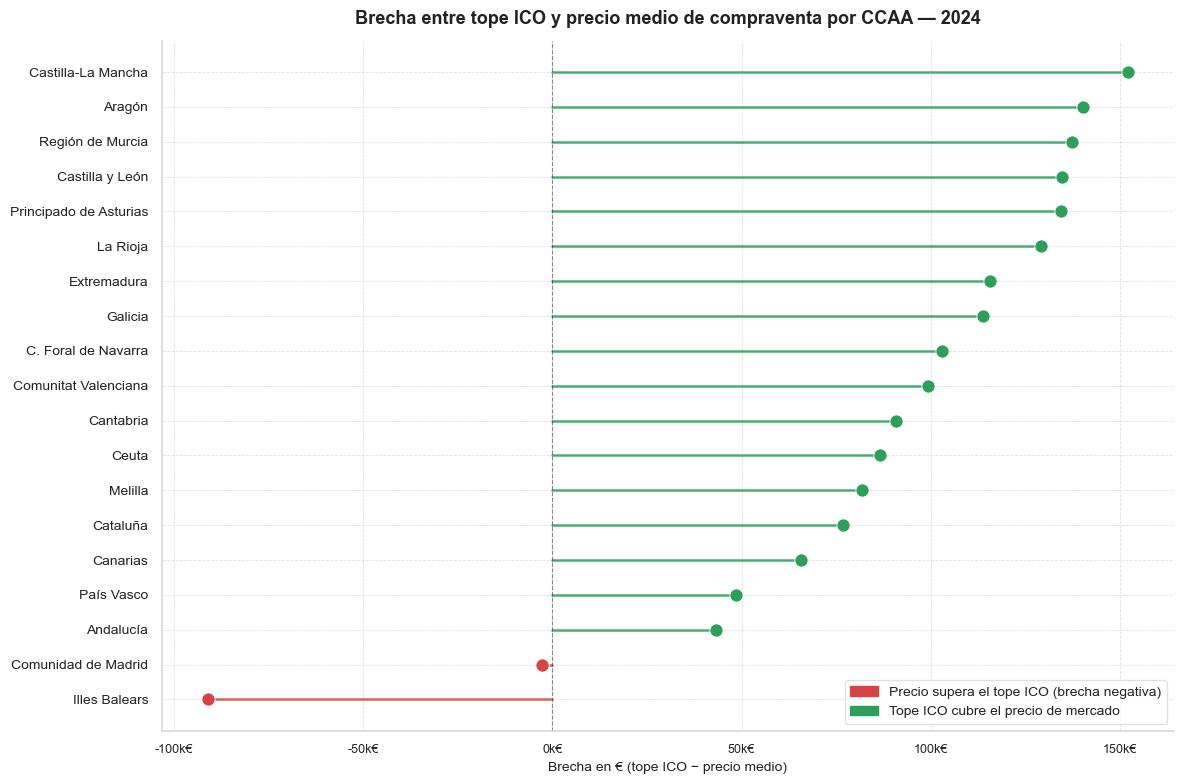

In [68]:
df_2024 = df_ccaa[df_ccaa["año"] == 2024].sort_values("brecha_ico", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
apply_light_style(ax, fig, grid_axis="both")

for i, (_, row) in enumerate(df_2024.iterrows()):
    color = NO_CUBIERTO if row["brecha_ico"] < 0 else CUBIERTO
    ax.plot([0, row["brecha_ico"]], [i, i], color=color, linewidth=1.8, alpha=0.85, zorder=1)
    ax.scatter(row["brecha_ico"], i, color=color, s=90, zorder=2,
               edgecolors="white", linewidths=0.6)

ax.axvline(0, color=TEXT, linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_yticks(range(len(df_2024)))
ax.set_yticklabels(df_2024["comunidad_autonoma"], fontsize=10)
ax.set_xlabel("Brecha en € (tope ICO − precio medio)", fontsize=10)
ax.set_title("Brecha entre tope ICO y precio medio de compraventa por CCAA — 2024",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))

patch_neg = mpatches.Patch(color=NO_CUBIERTO, label="Precio supera el tope ICO (brecha negativa)")
patch_pos = mpatches.Patch(color=CUBIERTO,    label="Tope ICO cubre el precio de mercado")
ax.legend(handles=[patch_neg, patch_pos], fontsize=10, loc="lower right",
          facecolor="white", edgecolor=GRID, labelcolor=TEXT)

plt.tight_layout()
plt.savefig("lollipop_brecha_ico_2024_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### Brecha entre tope ICO y precio medio de compraventa por CCAA — 2025

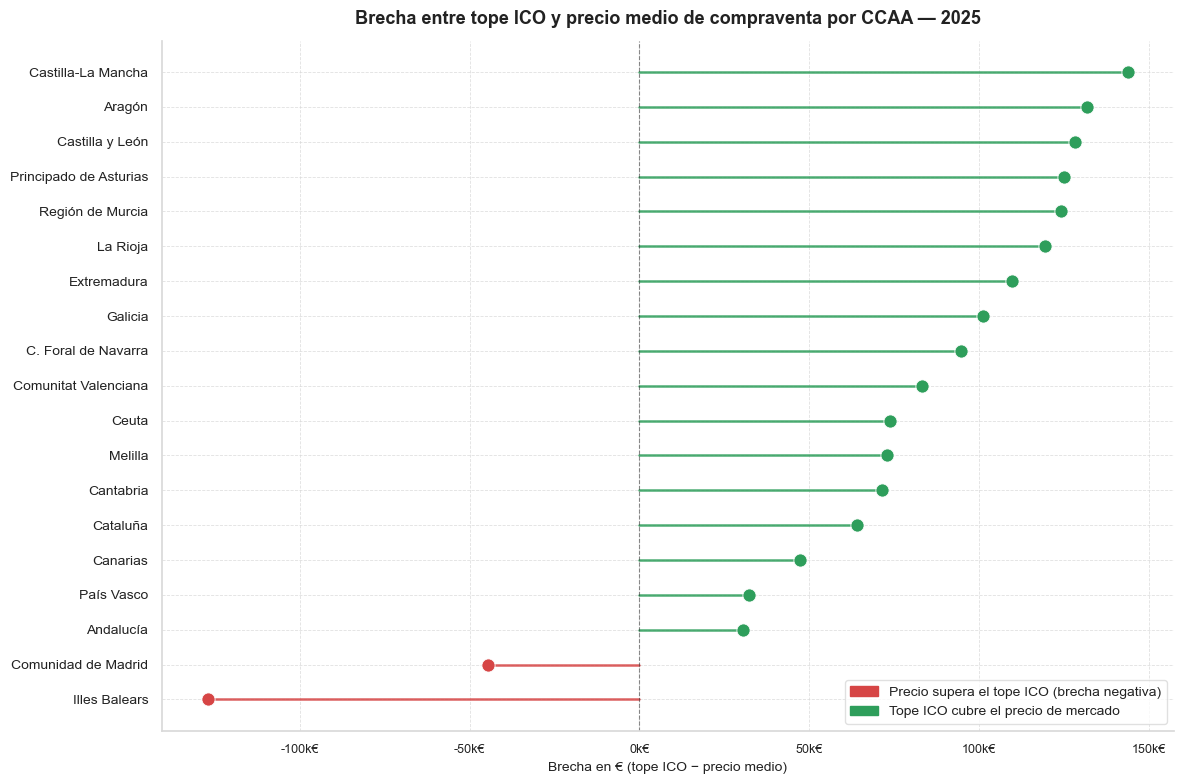

In [69]:
df_2025 = df_ccaa[df_ccaa["año"] == 2025].sort_values("brecha_ico", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
apply_light_style(ax, fig, grid_axis="both")

for i, (_, row) in enumerate(df_2025.iterrows()):
    color = NO_CUBIERTO if row["brecha_ico"] < 0 else CUBIERTO
    ax.plot([0, row["brecha_ico"]], [i, i], color=color, linewidth=1.8, alpha=0.85, zorder=1)
    ax.scatter(row["brecha_ico"], i, color=color, s=90, zorder=2,
               edgecolors="white", linewidths=0.6)

ax.axvline(0, color=TEXT, linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_yticks(range(len(df_2025)))
ax.set_yticklabels(df_2025["comunidad_autonoma"], fontsize=10)
ax.set_xlabel("Brecha en € (tope ICO − precio medio)", fontsize=10)
ax.set_title("Brecha entre tope ICO y precio medio de compraventa por CCAA — 2025",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))

patch_neg = mpatches.Patch(color=NO_CUBIERTO, label="Precio supera el tope ICO (brecha negativa)")
patch_pos = mpatches.Patch(color=CUBIERTO,    label="Tope ICO cubre el precio de mercado")
ax.legend(handles=[patch_neg, patch_pos], fontsize=10, loc="lower right",
          facecolor="white", edgecolor=GRID, labelcolor=TEXT)

plt.tight_layout()
plt.savefig("lollipop_brecha_ico_2025_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### Dispersión provincial vs tope ICO (2024 y 2025)

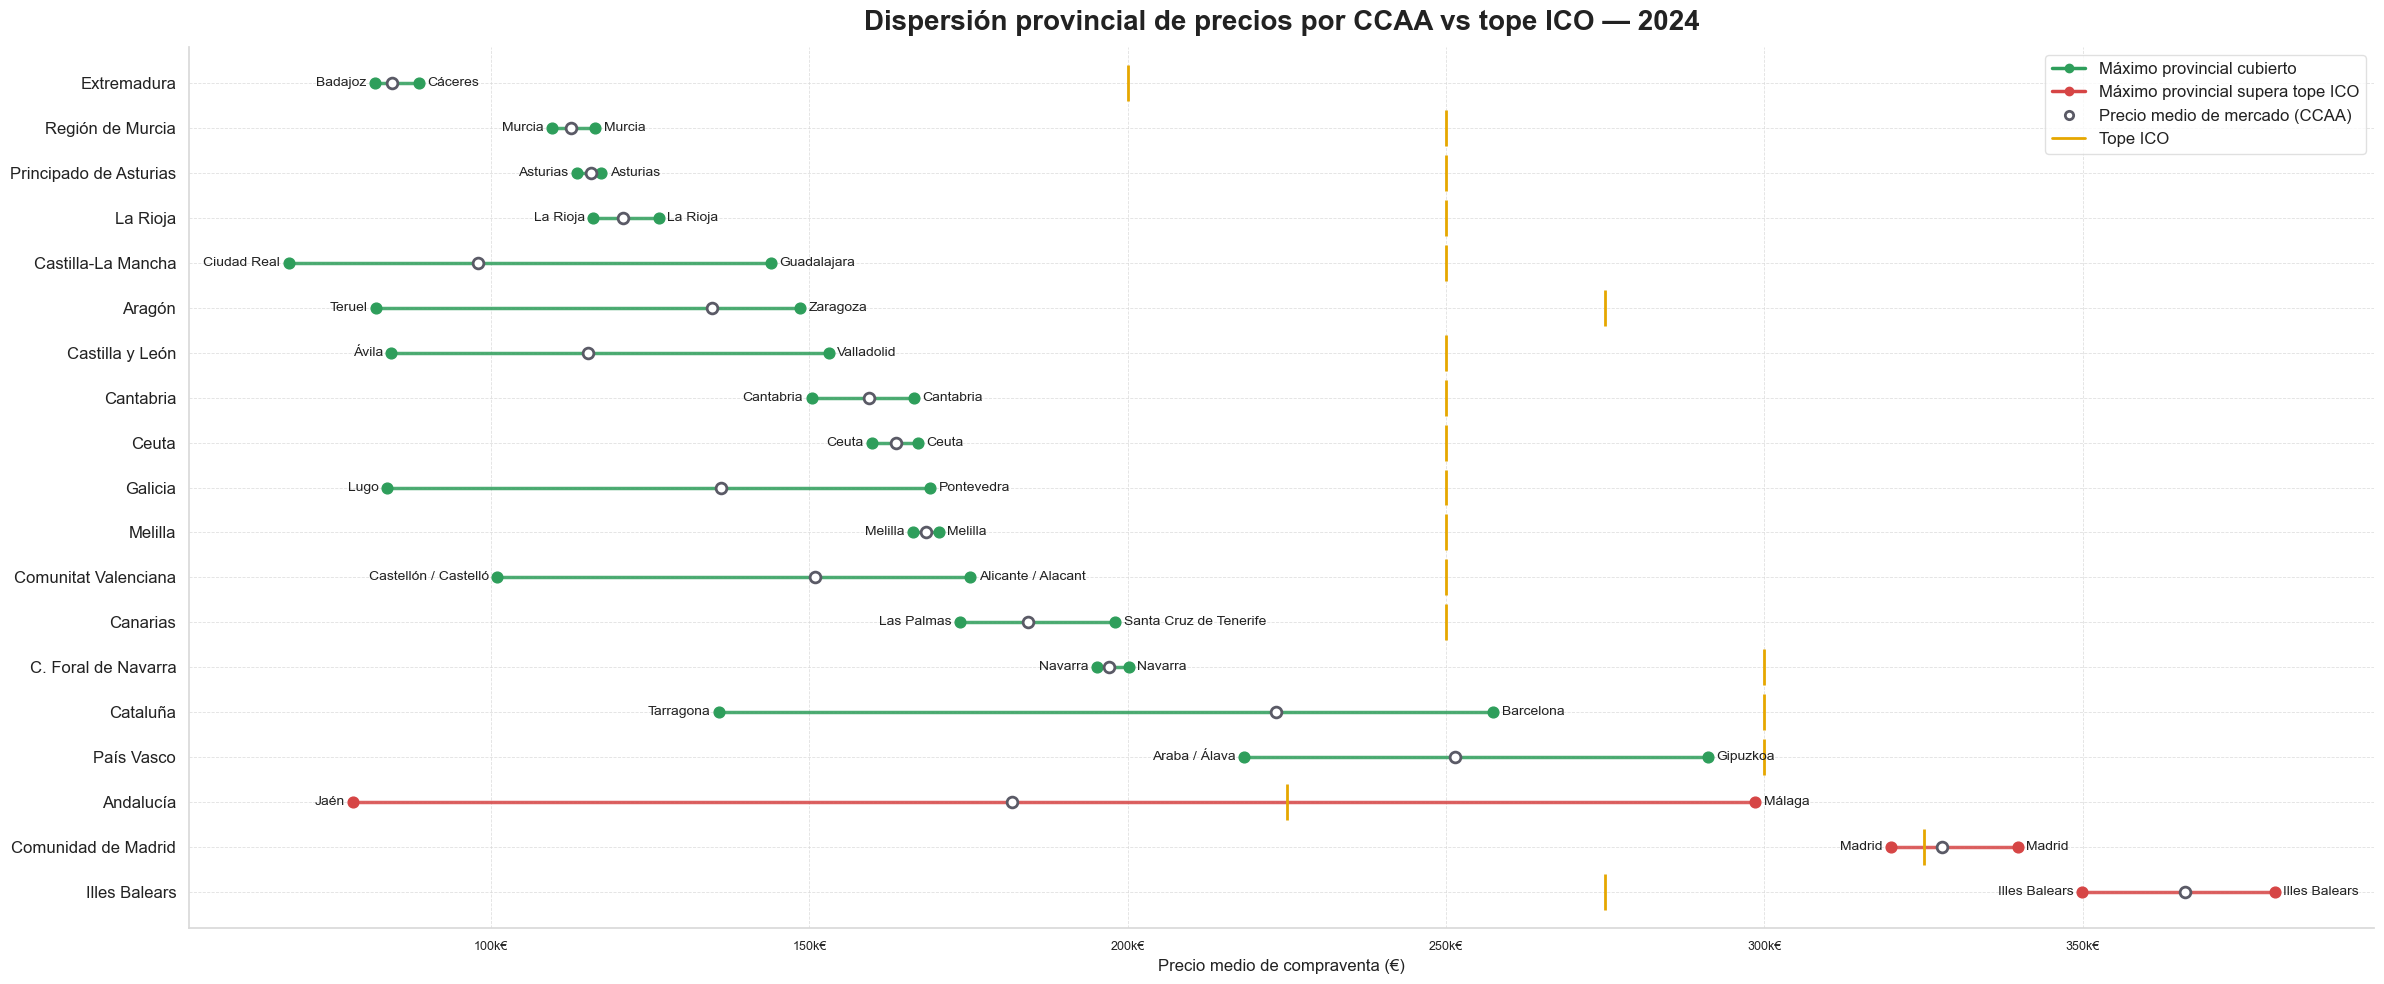

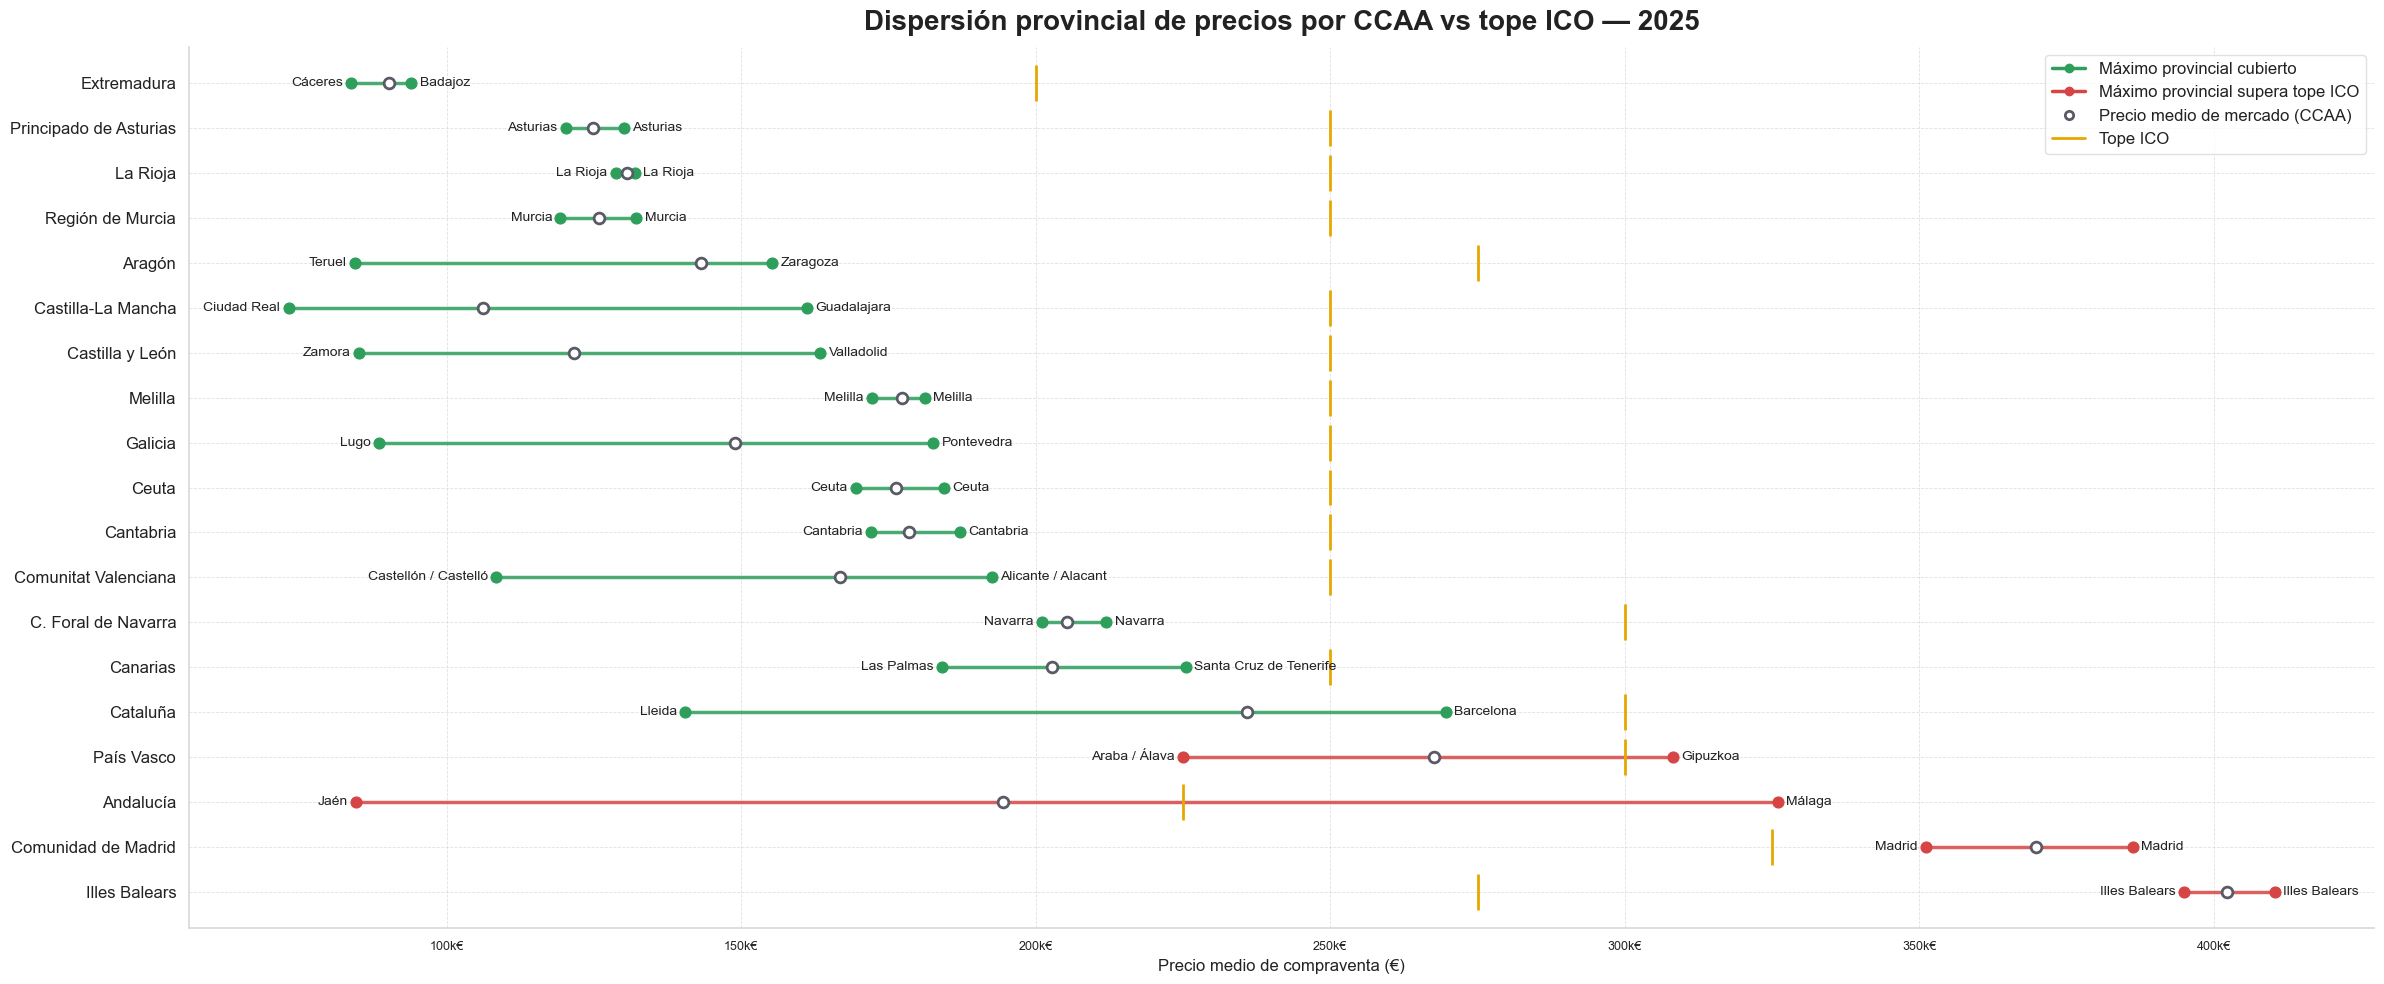

In [70]:
df_bloque1_prov = pd.merge(df_dispersion, df_ico, on="comunidad_autonoma", how="left")

df_bloque1_completo = pd.merge(
    df_bloque1_prov,
    df_ccaa[["comunidad_autonoma", "año", "precio_medio_compraventa"]],
    on=["comunidad_autonoma", "año"],
    how="left"
)

for año in [2024, 2025]:
    df_plot = (df_bloque1_completo[df_bloque1_completo["año"] == año]
               .sort_values("precio_maximo", ascending=False)
               .reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(24, 10))
    apply_light_style(ax, fig, grid_axis="both")

    for i, (_, row) in enumerate(df_plot.iterrows()):
        color = NO_CUBIERTO if row["precio_maximo"] > row["tope_ico"] else CUBIERTO

        ax.hlines(y=i, xmin=row["precio_minimo"], xmax=row["precio_maximo"],
                  color=color, linewidth=2.5, alpha=0.85, zorder=1)
        ax.scatter(row["precio_minimo"], i, color=color, s=60, zorder=3)
        ax.scatter(row["precio_maximo"], i, color=color, s=60, zorder=3)
        ax.scatter(row["precio_medio_compraventa"], i,
                   facecolors="white", edgecolors=MERCADO,
                   s=60, linewidth=2, zorder=4)
        ax.annotate(row["provincia_minimo"],
                    xy=(row["precio_minimo"], i), xytext=(-6, 0),
                    textcoords="offset points",
                    fontsize=10, ha="right", va="center", color=TEXT)
        ax.annotate(row["provincia_maximo"],
                    xy=(row["precio_maximo"], i), xytext=(6, 0),
                    textcoords="offset points",
                    fontsize=10, ha="left", va="center", color=TEXT)
        ax.vlines(x=row["tope_ico"], ymin=i - 0.4, ymax=i + 0.4,
                  color=TOPE_ICO, linewidth=2, linestyle="-", zorder=2)

    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot["comunidad_autonoma"], fontsize=12)
    ax.set_ylim(-0.8, len(df_plot) - 0.2)
    ax.set_xlabel("Precio medio de compraventa (€)", fontsize=12)
    ax.set_title(f"Dispersión provincial de precios por CCAA vs tope ICO — {año}",
                 fontsize=20, fontweight="bold", pad=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))

    patch_ok    = mlines.Line2D([], [], color=CUBIERTO, linewidth=2.5,
                                marker="o", markersize=6,
                                label="Máximo provincial cubierto")
    patch_no    = mlines.Line2D([], [], color=NO_CUBIERTO, linewidth=2.5,
                                marker="o", markersize=6,
                                label="Máximo provincial supera tope ICO")
    punto_medio = mlines.Line2D([], [], color=MERCADO, linewidth=0,
                                marker="o", markersize=6,
                                markerfacecolor="white",
                                markeredgecolor=MERCADO, markeredgewidth=2,
                                label="Precio medio de mercado (CCAA)")
    linea_ico   = mlines.Line2D([], [], color=TOPE_ICO, linewidth=2,
                                linestyle="-", label="Tope ICO")

    ax.legend(handles=[patch_ok, patch_no, punto_medio, linea_ico],
              fontsize=12, loc="upper right",
              facecolor="white", edgecolor=GRID, labelcolor=TEXT)

    plt.tight_layout()
    plt.savefig(f"rangeplot_dispersion_provincial_{año}_v2.png",
                dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


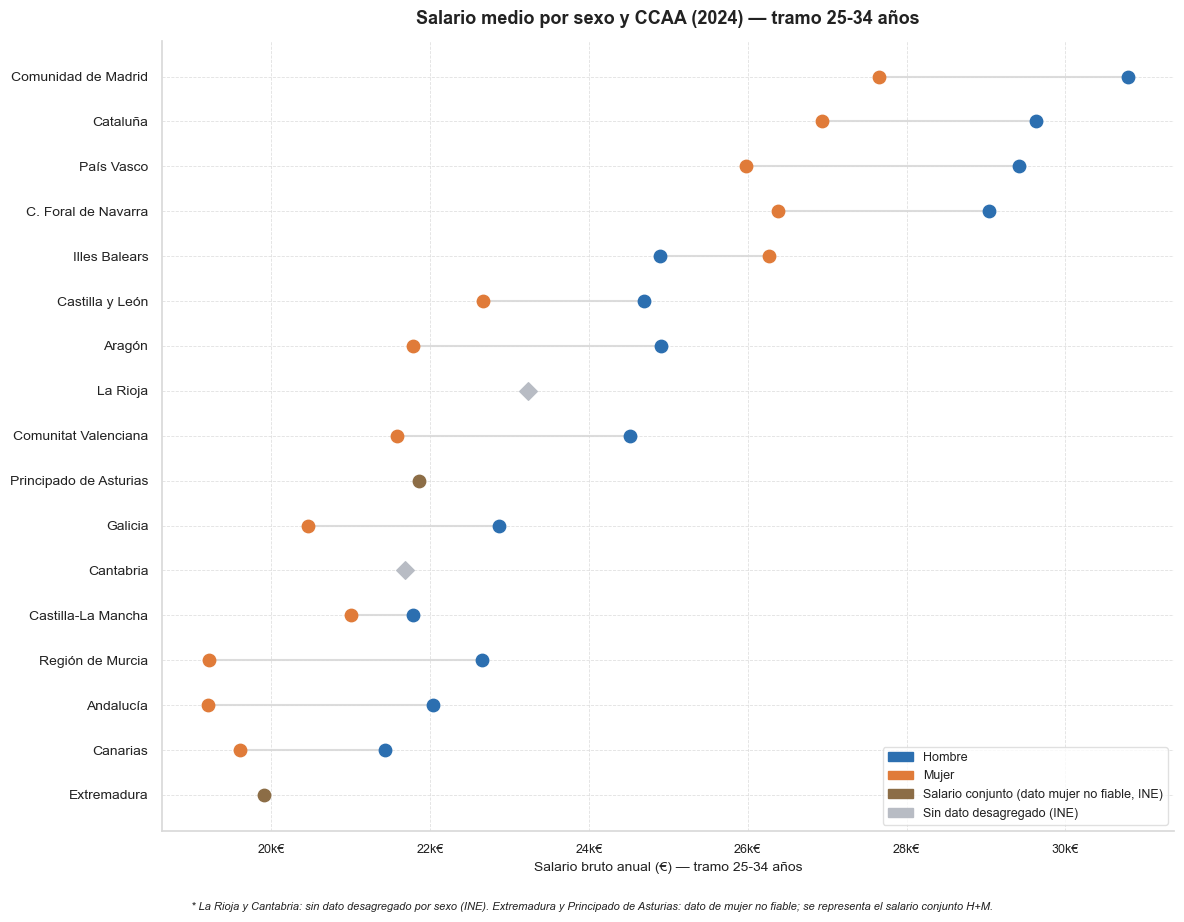

In [71]:
df_plot = df_salario_pivot.sort_values("salario_HyM", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 9))
apply_light_style(ax, fig, grid_axis="both")

for i, (_, row) in enumerate(df_plot.iterrows()):
    sal_h = row["salario_H"]
    sal_m = row["salario_M"]

    if pd.notna(sal_h) and pd.notna(sal_m):
        # Caso normal: ambos datos disponibles
        ax.hlines(y=i, xmin=min(sal_h, sal_m), xmax=max(sal_h, sal_m),
                  color=GRID, linewidth=1.5, alpha=0.9, zorder=1)
        ax.scatter(sal_h, i, color=HOMBRE, s=80, zorder=3)
        ax.scatter(sal_m, i, color=MUJER,  s=80, zorder=3)

    elif pd.isna(sal_h) and pd.isna(sal_m):
        # Sin dato desagregado: solo dato conjunto
        ax.scatter(row["salario_HyM"], i, color=SIN_DATO, s=80, zorder=3, marker="D")

    else:
        # Un sexo sin dato fiable: solo el agregado conjunto
        ax.scatter(row["salario_HyM"], i, color=CONJUNTO, s=80, zorder=3)

ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot["comunidad_autonoma"], fontsize=10)
ax.set_xlabel("Salario bruto anual (€) — tramo 25-34 años", fontsize=10)
ax.set_title("Salario medio por sexo y CCAA (2024) — tramo 25-34 años",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))

patch_h   = mpatches.Patch(color=HOMBRE,   label="Hombre")
patch_m   = mpatches.Patch(color=MUJER,    label="Mujer")
patch_hym = mpatches.Patch(color=CONJUNTO, label="Salario conjunto (dato mujer no fiable, INE)")
patch_na  = mpatches.Patch(color=SIN_DATO, label="Sin dato desagregado (INE)")
ax.legend(handles=[patch_h, patch_m, patch_hym, patch_na], fontsize=9,
          loc="lower right",
          facecolor="white", edgecolor=GRID, labelcolor=TEXT)

fig.text(0.5, -0.02,
         "* La Rioja y Cantabria: sin dato desagregado por sexo (INE). "
         "Extremadura y Principado de Asturias: dato de mujer no fiable; se representa el salario conjunto H+M.",
         ha="center", fontsize=8, color=TEXT, style="italic")

plt.tight_layout()
plt.savefig("salarios_ccaa_sexo_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### Capacidad financiera por CCAA y perfil

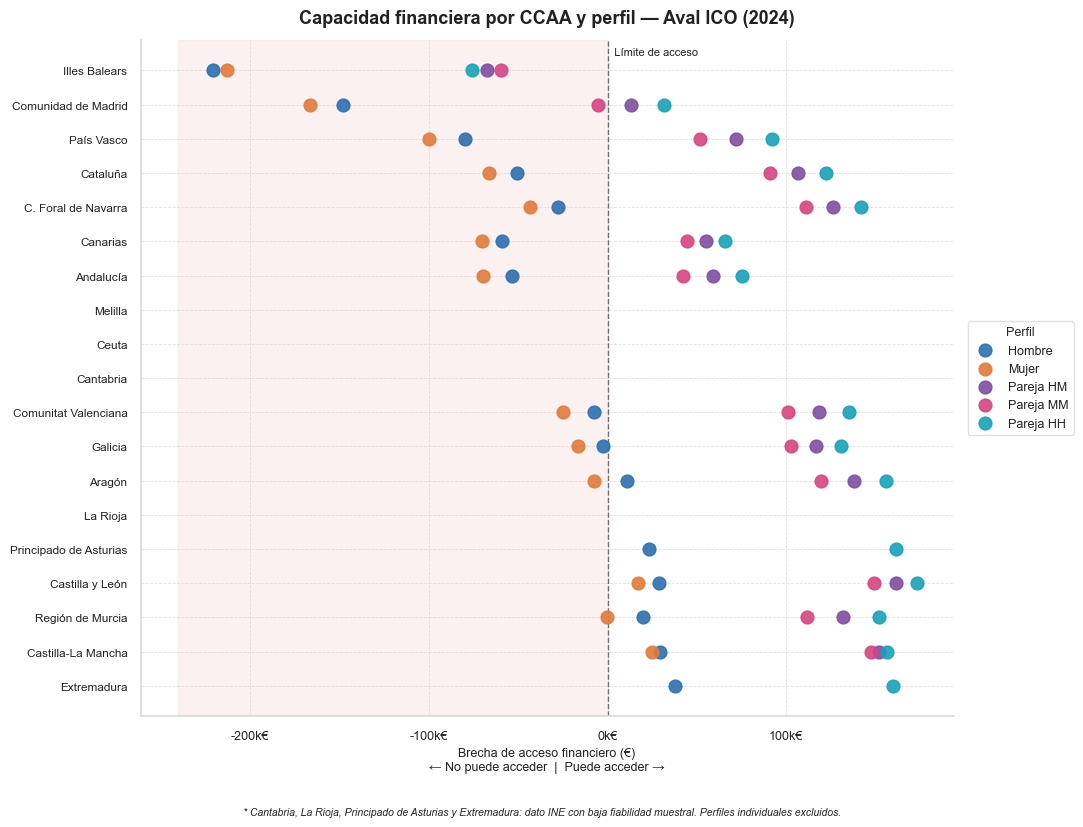

Guardada: dotplot_acceso_financiero_v2.png


In [72]:

perfiles_map = {
    "brecha_acceso_H":         "Hombre",
    "brecha_acceso_M":         "Mujer",
    "brecha_acceso_pareja_HM": "Pareja HM",
    "brecha_acceso_pareja_MM": "Pareja MM",
    "brecha_acceso_pareja_HH": "Pareja HH",
}

df_long = df_ccaa_salarios_2024[
    ["comunidad_autonoma", "precio_medio_compraventa"] + list(perfiles_map.keys())
].melt(
    id_vars=["comunidad_autonoma", "precio_medio_compraventa"],
    var_name="perfil_col",
    value_name="brecha_acceso"
)
df_long["perfil"] = df_long["perfil_col"].map(perfiles_map)

orden_ccaa = (df_ccaa_salarios_2024
              .sort_values("precio_medio_compraventa", ascending=True)["comunidad_autonoma"]
              .tolist())

paleta_perfiles = {
    "Hombre":     HOMBRE,
    "Mujer":      MUJER,
    "Pareja HM":  PAREJA_HM,
    "Pareja MM":  PAREJA_MM,
    "Pareja HH":  PAREJA_HH,
}

fig, ax = plt.subplots(figsize=(11, 8))
apply_light_style(ax, fig, grid_axis="both")

for perfil, color in paleta_perfiles.items():
    df_p = df_long[df_long["perfil"] == perfil]
    y_pos = [orden_ccaa.index(c) for c in df_p["comunidad_autonoma"] if c in orden_ccaa]
    vals  = [row["brecha_acceso"] for _, row in df_p.iterrows() if row["comunidad_autonoma"] in orden_ccaa]
    ax.scatter(vals, y_pos, color=color, label=perfil, s=85, alpha=0.9, zorder=3)

ax.axvline(0, color=TEXT, linewidth=1, linestyle="--", alpha=0.6)
ax.text(0, len(orden_ccaa) - 0.3, "  Límite de acceso",
        fontsize=8, color=TEXT, va="top")

# Banda de fondo para zona no accesible (brecha negativa)
ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] < 0 else -200000, 0,
           alpha=0.07, color=NO_CUBIERTO, zorder=0)

ax.set_yticks(range(len(orden_ccaa)))
ax.set_yticklabels(orden_ccaa, fontsize=8.5)
ax.set_xlabel("Brecha de acceso financiero (€)\n← No puede acceder  |  Puede acceder →",
              fontsize=9)
ax.set_title("Capacidad financiera por CCAA y perfil — Aval ICO (2024)",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))

ax.legend(title="Perfil", fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.01, 0.5), loc="center left",
          facecolor="white", edgecolor=GRID, labelcolor=TEXT)

fig.text(0.5, -0.03,
         "* Cantabria, La Rioja, Principado de Asturias y Extremadura: dato INE con baja fiabilidad muestral. "
         "Perfiles individuales excluidos.",
         ha="center", fontsize=7.5, color=TEXT, style="italic")

plt.tight_layout()
plt.savefig("dotplot_acceso_financiero_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Guardada: dotplot_acceso_financiero_v2.png")


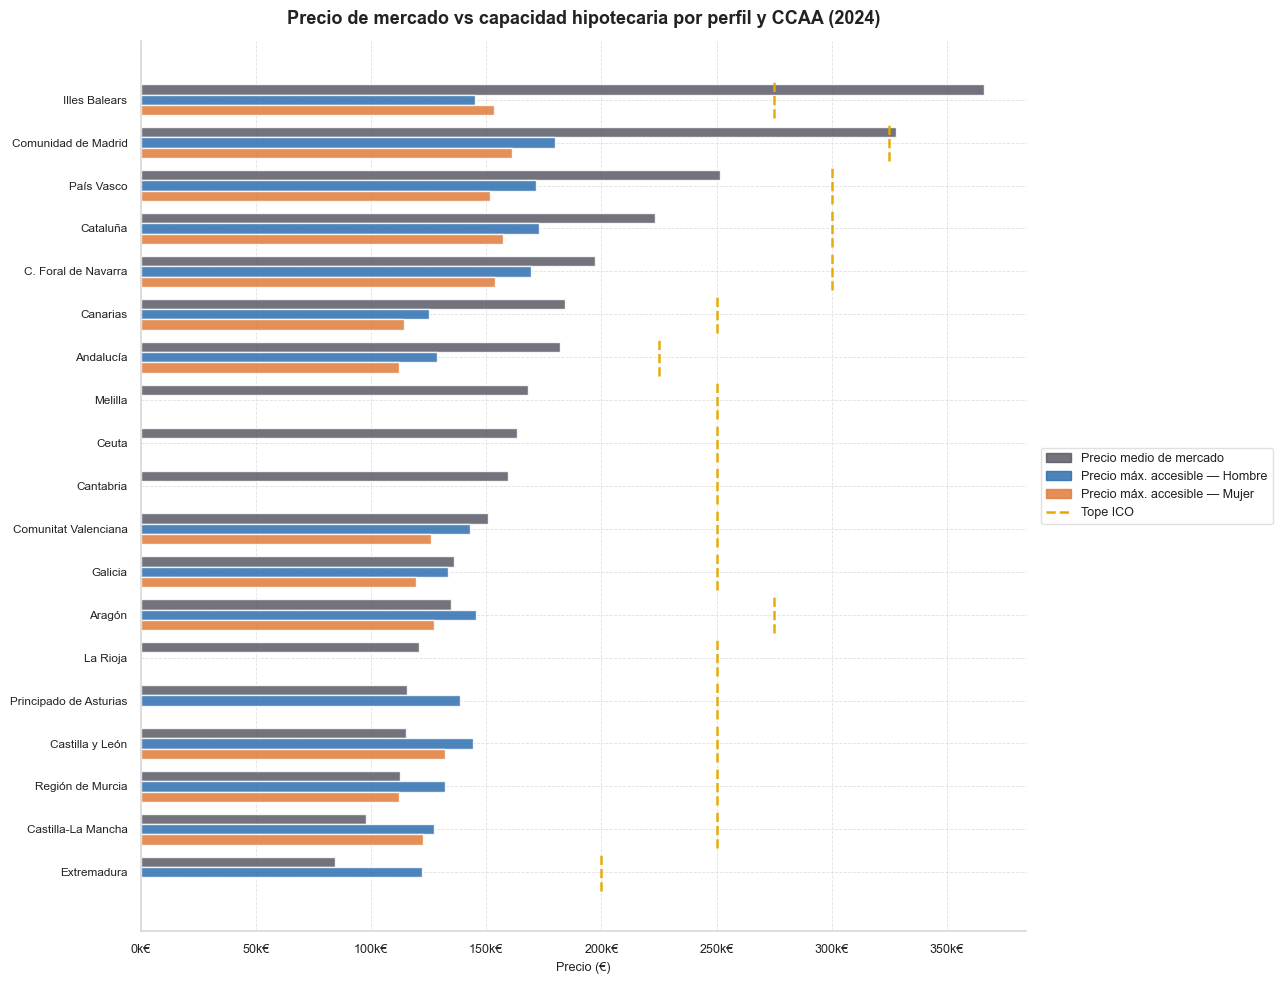

Guardada: barras_capacidad_hipotecaria_v2.png


In [73]:
df_plot = df_ccaa_salarios_2024.sort_values("precio_medio_compraventa", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10))
apply_light_style(ax, fig, grid_axis="both")

y = np.arange(len(df_plot))
alto = 0.24

ax.barh(y + alto, df_plot["precio_medio_compraventa"],
        height=alto, color=MERCADO, alpha=0.85, label="Precio medio de mercado")
ax.barh(y,         df_plot["precio_max_vivienda_H"],
        height=alto, color=HOMBRE,  alpha=0.85, label="Precio máx. accesible — Hombre")
ax.barh(y - alto,  df_plot["precio_max_vivienda_M"],
        height=alto, color=MUJER,   alpha=0.85, label="Precio máx. accesible — Mujer")

for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.vlines(x=row["tope_ico"], ymin=i - alto * 1.8, ymax=i + alto * 1.8,
              color=TOPE_ICO, linewidth=1.8, linestyle="--", zorder=4, alpha=0.95)

ax.set_yticks(y)
ax.set_yticklabels(df_plot["comunidad_autonoma"], fontsize=8.5)
ax.set_xlabel("Precio (€)", fontsize=9)
ax.set_title("Precio de mercado vs capacidad hipotecaria por perfil y CCAA (2024)",
             fontsize=13, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))

patch_mercado = mpatches.Patch(color=MERCADO, alpha=0.85, label="Precio medio de mercado")
patch_h       = mpatches.Patch(color=HOMBRE,  alpha=0.85, label="Precio máx. accesible — Hombre")
patch_m       = mpatches.Patch(color=MUJER,   alpha=0.85, label="Precio máx. accesible — Mujer")
line_ico      = mlines.Line2D([], [], color=TOPE_ICO, linewidth=1.8,
                               linestyle="--", label="Tope ICO")

ax.legend(handles=[patch_mercado, patch_h, patch_m, line_ico],
          fontsize=9, bbox_to_anchor=(1.01, 0.5), loc="center left",
          facecolor="white", edgecolor=GRID, labelcolor=TEXT)

plt.tight_layout()
plt.savefig("barras_capacidad_hipotecaria_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Guardada: barras_capacidad_hipotecaria_v2.png")
